# Análisis Financiero · 10.000 Empresas más Grandes de Colombia

**Fuente:** Superintendencia de Sociedades de Colombia  
**Corte:** 31 de diciembre de 2024  
**Autor:** Alejandro Castro Montoya  
**Herramientas:** Python · pandas · numpy · matplotlib · seaborn  

---

## `Objetivo`

Ir más allá del tamaño por ingresos: identificar qué empresas y sectores combinan
mayor rentabilidad con menor riesgo financiero, usando datos oficiales reales
publicados por la Superintendencia de Sociedades.

1. ¿Qué macrosectores generan mayor rentabilidad (ROE, margen neto)?
2. ¿Qué sectores presentan mayor riesgo de endeudamiento?
3. ¿Qué empresas crecieron más entre 2023 y 2024 manteniendo salud financiera?
4. ¿Cómo se distribuye la eficiencia financiera por región y grupo NIIF?

---
## 1. Configuración e Importaciones

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.options.display.float_format = '{:,.2f}'.format

# Estilo global para todas las gráficas del proyecto
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
## 2. Carga y exploracion inicial

Se cargan dos archivos oficiales de Supersociedades:
- `Base_1000_empresas_2024.xlsx` → Top 1.000 por ingresos operacionales
- `Base_9000_empresas_2024.csv` → Siguientes 9.000 empresas

In [96]:
ruta_1000 = Path('../datos/Base_1000_empresas_2024.xlsx')
ruta_9000 = Path('../datos/Base_9000_empresas_2024.csv')

# Los encabezados reales comienzan en la fila 4 (índice 4) en ambos archivos
df_1000 = pd.read_excel(ruta_1000, header=4)
df_9000 = pd.read_csv(ruta_9000, encoding='latin-1', sep=';', header=4)


display(df_1000.head(3))
display(df_9000.head(3))

,No.,NIT,RAZON SOCIAL,SUPERVISOR,REGION,DEPARTAMENTO DOMICILIO,CIUDAD DOMICILIO,CIIU,MACROSECTOR,INGRESOS OPERACIONALES\n2024*,GANANCIA (PERDIDA) 2024,TOTAL ACTIVOS 2024,TOTAL PASIVOS 2024,TOTAL PATRIMONIO 2024,INGRESOS OPERACIONALES\n2023*,GANANCIA (PERDIDA) 2023,TOTAL ACTIVOS 2023,TOTAL PASIVOS 2023,TOTAL PATRIMONIO 2023,GRUPO EN NIIF
0,1,899999068,ECOPETROL S.A,SUPERFINANCIERA,Bogotá - Cundinamarca,BOGOTA D.C.,BOGOTA D.C.,B0610 - Extracción de petróleo crudo,MINERO-HIDROCARBUROS,113923310323,14934704562,214240962390,130544063451,83696898939,"129,508,676,028.00","19,062,090,906.00","198,732,048,468.00","120,339,989,405.00","78,392,059,063.00",GRUPO 1
1,2,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,Costa Atlántica,BOLIVAR,CARTAGENA,"C1921 - Coquización, fabricación de productos ...",MANUFACTURA,25860914507,-262862567,39503859530,11927362818,27576496712,"32,050,663,229.00","3,491,071,128.00","37,267,017,658.00","12,526,423,635.00","24,740,594,023.00",GRUPO 1
2,3,830095213,ORGANIZACIÓN TERPEL S.A.,SUPERFINANCIERA,Bogotá - Cundinamarca,BOGOTA D.C.,BOGOTA D.C.,G4661 - Comercio al por mayor de combustibles ...,COMERCIO,24752011682,530755958,7971211913,4621825212,3349386701,"23,048,284,871.00","285,273,513.00","7,357,710,447.00","4,606,665,920.00","2,751,044,527.00",GRUPO 1


,RANKING,NIT,RAZON SOCIAL,SUPERVISOR,REGION,DEPARTAMENTO DOMICILIO,CIUDAD DOMICILIO,CIIU,MACROSECTOR,INGRESOS OPERACIONALES 2024*,GANANCIA (PERDIDA) 2024,TOTAL ACTIVOS 2024,TOTAL PASIVOS 2024,TOTAL PATRIMONIO 2024,Unnamed: 14,INGRESOS OPERACIONALES 2023*,GANANCIA (PERDIDA) 2023,TOTAL ACTIVOS 2023,TOTAL PASIVOS 2023,TOTAL PATRIMONIO 2023,Punto de entrada
0,1001,900579611,CONSUMER ELECTRONICS GROUP SAS,SUPERSOCIEDADES,Eje Cafetero,RISARALDA,PEREIRA,C2640 - Fabricación de aparatos electrónicos d...,MANUFACTURA,269.035.796,5.419.405,240.848.540,203.826.219,37.022.321,NaN,240.068.436,10.146.405,157.174.090,125.966.423,31.207.667,50 NIIF Pymes - Separado Grupo 2
1,1002,830131993,EFECTIVO LTDA,SUPERSOCIEDADES,Bogotá - Cundinamarca,BOGOTA D.C.,"BOGOTÁ, D.C.",N8299 - Otras actividades de servicio de apoyo...,SERVICIOS,268.922.021,6.384.114,349.261.216,213.173.133,136.088.083,NaN,350.686.512,23.329.815,399.417.768,269.713.799,129.703.969,20 NIIF Plenas - Separado Grupo 1
2,1003,800136561,Urbanizadora Santa fe de Bogota Urbansa SA,SUPERSOCIEDADES,Bogotá - Cundinamarca,BOGOTA D.C.,"BOGOTÁ, D.C.",F4111 - Construcción de edificios residenciales,CONSTRUCCIÓN,268.820.379,14.653.783,460.878.581,274.812.767,186.065.814,NaN,248.098.185,14.390.716,450.914.278,281.696.844,169.217.434,20 NIIF Plenas - Separado Grupo 1


---
## 3. Limpieza y Estandarizacion

Pasos aplicados para la limpieza:
- Estandarización de nombres de columnas (eliminación de saltos de línea y espacios)
- Conversión de variables financieras a tipo numérico
- Revisión de nulos: se conservan dado su baja proporción (<0.5%)
  para no distorsionar rankings ni estadísticas agregadas por sector

In [97]:
def limpiar_columnas(df):
    df = df.dropna(axis=1, how='all')

    df.columns = (
        df.columns
        .str.strip()
        .str.replace("\n", " ", regex=False)
        .str.upper())
    return df

# Limpieza de columna
df_1000 = limpiar_columnas(df_1000)
df_9000 = limpiar_columnas(df_9000)

# Estandarizacion
df_1000 = df_1000.rename(columns={"NO.": "RANKING"})
df_9000 = df_9000.rename(columns={"PUNTO DE ENTRADA": "GRUPO EN NIIF"})

columnas_financieras = [
    "INGRESOS OPERACIONALES 2024*",
    "GANANCIA (PERDIDA) 2024",
    "TOTAL ACTIVOS 2024",
    "TOTAL PASIVOS 2024",
    "TOTAL PATRIMONIO 2024",
    "INGRESOS OPERACIONALES 2023*",
    "GANANCIA (PERDIDA) 2023",
    "TOTAL ACTIVOS 2023",
    "TOTAL PASIVOS 2023",
    "TOTAL PATRIMONIO 2023"]

# Limpiar xlsx
for col in columnas_financieras:
    df_1000[col] = pd.to_numeric(df_1000[col],errors='coerce')

# Limpiar csv
def limpiar_csv_financiero(df, columnas):
    for col in columnas:
        df[col] = (df[col]
            .astype(str)
            .str.strip()
            .str.replace("$", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False))
        df[col] = pd.to_numeric(df[col],errors='coerce')
    return df

df_9000 = limpiar_csv_financiero(df_9000,columnas_financieras)


---
## 4. Unificacion de datasets

Ambas bases de datos se unifican en un único DataFrame de 10.000 registros.

In [98]:
df = pd.concat([df_1000, df_9000],ignore_index=True) # Dataset completo 10.000 empresas mas grandes

print(df.shape)
df.info()

(10000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   RANKING                       10000 non-null  int64  
 1   NIT                           10000 non-null  int64  
 2   RAZON SOCIAL                  10000 non-null  str    
 3   SUPERVISOR                    10000 non-null  str    
 4   REGION                        10000 non-null  str    
 5   DEPARTAMENTO DOMICILIO        10000 non-null  str    
 6   CIUDAD DOMICILIO              10000 non-null  str    
 7   CIIU                          10000 non-null  str    
 8   MACROSECTOR                   10000 non-null  str    
 9   INGRESOS OPERACIONALES 2024*  10000 non-null  int64  
 10  GANANCIA (PERDIDA) 2024       9994 non-null   float64
 11  TOTAL ACTIVOS 2024            10000 non-null  int64  
 12  TOTAL PASIVOS 2024            10000 non-null  int64  
 13  T

In [99]:
df[columnas_financieras] = df[columnas_financieras].astype(float)

# Limpieza Grupo en NIIF
df["GRUPO EN NIIF"] = (
    df["GRUPO EN NIIF"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"414": "NO REPORTADO",
              "414.0": "NO REPORTADO",
              "NAN": "NO REPORTADO",
              "": "NO REPORTADO"})
    # Completar nulos reales
    .fillna("NO REPORTADO").astype("string"))

# Limpiar columnas de Region-Ciudad-Departamento
# Limpieza general
for col in ['REGION', 'DEPARTAMENTO DOMICILIO', 'CIUDAD DOMICILIO']:
    df[col] = (df[col].astype(str).str.strip().str.upper())
df.loc[df['CIUDAD DOMICILIO'] == 'BOGOTA D.C.','DEPARTAMENTO DOMICILIO'] = 'BOGOTA D.C.'

df['DEPARTAMENTO DOMICILIO'] = (df['DEPARTAMENTO DOMICILIO']
    .replace({'ARMENIA': 'QUINDIO','MONTERIA': 'CORDOBA','VALLEDUPAR': 'CESAR','NARINO': 'NARIÑO'}))

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   RANKING                       10000 non-null  int64  
 1   NIT                           10000 non-null  int64  
 2   RAZON SOCIAL                  10000 non-null  str    
 3   SUPERVISOR                    10000 non-null  str    
 4   REGION                        10000 non-null  str    
 5   DEPARTAMENTO DOMICILIO        10000 non-null  str    
 6   CIUDAD DOMICILIO              10000 non-null  str    
 7   CIIU                          10000 non-null  str    
 8   MACROSECTOR                   10000 non-null  str    
 9   INGRESOS OPERACIONALES 2024*  10000 non-null  float64
 10  GANANCIA (PERDIDA) 2024       9994 non-null   float64
 11  TOTAL ACTIVOS 2024            10000 non-null  float64
 12  TOTAL PASIVOS 2024            10000 non-null  float64
 13  TOTAL PATRIMO

None

---
## 5. Construcción de KPIs Financieros

Se calculan los indicadores clave para 2023 y 2024:

| KPI | Fórmula | Qué mide |
|-----|---------|----------|
| **Margen Neto** | Ganancia / Ingresos × 100 | Eficiencia operativa |
| **ROA** | Ganancia / Activos × 100 | Rentabilidad de los activos |
| **ROE** | Ganancia / Patrimonio × 100 | Rentabilidad para el accionista |
| **Solvencia** | Activos / Pasivos | Capacidad de cubrir deudas |
| **Endeudamiento** | Pasivos / Patrimonio | Nivel de apalancamiento |
| **Crecimiento Ingresos** | (Ingresos 2024 − 2023) / 2023 × 100 | Variación real año a año |

> **Nota técnica:** Los denominadores en cero se reemplazan por NaN para
> evitar divisiones indefinidas. Los valores extremos (outliers) existen
> y se tratan en el análisis exploratorio con filtros contextuales.

In [100]:
def calcular_kpis(df, anio):
    ingresos = f'INGRESOS OPERACIONALES {anio}*'
    ganancia = f'GANANCIA (PERDIDA) {anio}'
    activos = f'TOTAL ACTIVOS {anio}'
    pasivos = f'TOTAL PASIVOS {anio}'
    patrimonio = f'TOTAL PATRIMONIO {anio}'

    # Margen neto
    df[f'MARGEN NETO {anio}'] = (df[ganancia] / df[ingresos].replace(0, np.nan)) * 100
    # ROA
    df[f'ROA {anio}'] = (df[ganancia] / df[activos].replace(0, np.nan)) * 100
    # ROE
    df[f'ROE {anio}'] = (df[ganancia] / df[patrimonio].replace(0, np.nan)) * 100
    # Solvencia
    df[f'SOLVENCIA {anio}'] = (df[activos] / df[pasivos].replace(0, np.nan))
    # Endeudamiento
    df[f'ENDEUDAMIENTO {anio}'] = (df[pasivos] / df[patrimonio].replace(0, np.nan))
    return df

# Crecimiento de ingresos 23-24
df['CRECIMIENTO INGRESOS %'] = (
    (df['INGRESOS OPERACIONALES 2024*'] - df['INGRESOS OPERACIONALES 2023*']) /
    df['INGRESOS OPERACIONALES 2023*'].replace(0, np.nan) ) * 100

# Cuartiles por tamaño de ingreo operacional
df['TAMAÑO EMPRESA'] = pd.qcut(df['INGRESOS OPERACIONALES 2024*'],q=4,labels=['Pequeña','Mediana','Grande','Muy Grande'])

# KPIs para el 2023 y 2024
df = calcular_kpis(df, 2023)
df = calcular_kpis(df, 2024)

print('KPIs calculados para 2023 y 2024')
print(f'  Columnas totales en el dataset: {df.shape[1]}')


KPIs calculados para 2023 y 2024
  Columnas totales en el dataset: 32


In [101]:
def resumen_kpis(df, anio):

    kpis = [f'MARGEN NETO {anio}',
            f'ROA {anio}',
            f'ROE {anio}',
            f'SOLVENCIA {anio}',
            f'ENDEUDAMIENTO {anio}']

    resumen = pd.DataFrame({
        'KPI': kpis,
        'N válidos': [df[col].count() for col in kpis],
        'Q1 (25%)': [df[col].quantile(0.25)for col in kpis],
        'Mediana': [df[col].median() for col in kpis],
        'Q3 (75%)': [df[col].quantile(0.75) for col in kpis],
        'IQR': [df[col].quantile(0.75) - df[col].quantile(0.25) for col in kpis]
        })
    return resumen.round(2)

resumen_2024 = resumen_kpis(df, 2024)
resumen_2023 = resumen_kpis(df, 2023)

print('── Resumen KPIs 2024 ──')
display(resumen_2024)
print('── Resumen KPIs 2023 ──')
display(resumen_2023)


── Resumen KPIs 2024 ──


,KPI,N válidos,Q1 (25%),Mediana,Q3 (75%),IQR
0,MARGEN NETO 2024,9994,0.81,3.21,7.54,6.72
1,ROA 2024,9994,1.39,4.85,10.13,8.75
2,ROE 2024,9994,4.32,11.97,22.48,18.17
3,SOLVENCIA 2024,10000,1.41,1.83,2.70,1.29
4,ENDEUDAMIENTO 2024,10000,0.54,1.14,2.26,1.72


── Resumen KPIs 2023 ──


,KPI,N válidos,Q1 (25%),Mediana,Q3 (75%),IQR
0,MARGEN NETO 2023,9952,0.98,3.49,7.62,6.64
1,ROA 2023,9965,1.59,5.39,10.77,9.18
2,ROE 2023,9965,4.61,13.27,24.67,20.05
3,SOLVENCIA 2023,9973,1.40,1.79,2.58,1.18
4,ENDEUDAMIENTO 2023,9973,0.59,1.20,2.32,1.73


## Conclusiones iniciales de los KPIs financieros (2023 vs 2024)

Para el análisis general de las 10.000 empresas se utilizaron medidas robustas como la mediana y los cuartiles (Q1 y Q3), debido a la alta presencia de outliers y diferencias de tamaño entre compañías. Este enfoque permite representar de mejor manera a la empresa “típica” colombiana.

Al comparar 2023 frente a 2024, se observa una leve disminución en indicadores clave de rentabilidad y eficiencia como el Margen Neto, ROA y ROE. Aunque las empresas en términos generales continuaron creciendo en ingresos operacionales, la reducción en estos indicadores sugiere que dicho crecimiento no necesariamente se tradujo en una mayor rentabilidad. Esto podría estar asociado a incrementos en costos operativos, gastos financieros, presión inflacionaria o menores niveles de eficiencia en el uso de los activos y el patrimonio.


Sin embargo, este análisis aún corresponde a una visión agregada del conjunto empresarial colombiano. Debido a que el dataset mezcla múltiples sectores económicos con comportamientos financieros muy diferentes, el siguiente paso será segmentar la información por variables como:

- Macrosector
- Grupo en NIIF
- Región o ubicación geográfica
- Tamaño relativo de las compañías

Esto permitirá identificar patrones más específicos y comprender qué sectores o tipos de empresas están impulsando las variaciones observadas en los KPIs financieros.

---
## 6. Análisis Exploratorio de Datos (EDA)

Cada visualización responde una pregunta de negocio concreta.
Se usan medianas por sector para evitar que outliers distorsionen las conclusiones.

In [102]:
# FUNCIONES AUXILIARES

# Graficar la composicion por segmentos de interes
def graficar_composicion(df,columna,titulo,ax,top_n=None):

    # Conteo de categorías
    conteo = (df[columna].value_counts().reset_index())
    # Renombrar columnas
    conteo.columns = ['Categoria', 'Empresas']
    # Limitar Top N si se especifica
    if top_n:
        conteo = conteo.head(top_n)

    # Gráfica
    sns.barplot(data=conteo,x='Empresas',y='Categoria',hue='Categoria',palette='Blues_r',legend=False,ax=ax)

    # Títulos
    ax.set_title(titulo,fontsize=12,fontweight='bold',pad=10)
    ax.set_xlabel('Número de empresas')
    ax.set_ylabel('')

    # Etiquetas de valores
    for bar in ax.patches:
        ax.text(
            bar.get_width() + (conteo['Empresas'].max() * 0.01),
            bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}',
            va='center',
            fontsize=9)

# Graficar el desempeño (KPIs) por segmentos
def graficar_kpi_segmento(df,columna_segmento,columna_kpi,titulo,ax,top_n=None,agrupar=True):
    
    # ── Filtrado robusto de outliers
    p1 = df[columna_kpi].quantile(0.05)
    p99 = df[columna_kpi].quantile(0.95)

    df_filtrado = df[df[columna_kpi].between(p1, p99)].copy()

    # ── Calcular mediana por segmento
    resumen = (df_filtrado.groupby(columna_segmento)[columna_kpi].median().sort_values(ascending=False).reset_index())

    # Limitar top N
    if top_n:
        resumen = resumen.head(top_n)

    # ── Gráfica
    bars = ax.barh(resumen[columna_segmento],resumen[columna_kpi],color=sns.color_palette('Blues_r', len(resumen)))
    ax.invert_yaxis()
    ax.axvline(0,color='black',linewidth=0.8,linestyle='--')

    # Título
    ax.set_title(titulo,fontsize=12,fontweight='bold',pad=10)
    ax.set_xlabel('Margen neto mediano (%)')
    ax.set_ylabel('')

    # ── Etiquetas
    for bar, val in zip(bars, resumen[columna_kpi]):
        ax.text(val + 0.3,bar.get_y() + bar.get_height() / 2,f'{val:.1f}%',va='center',fontsize=9)

# Graficar Histograma por KPI
def graficar_distribucion_kpi(df,columna_segmento,columna_kpi,titulo,ax,bins=40,top_n=5,percentil_inf=0.05,percentil_sup=0.95):

    # ── Filtrado robusto del KPI
    p_inf = df[columna_kpi].quantile(percentil_inf)
    p_sup = df[columna_kpi].quantile(percentil_sup)

    df_filtrado = df[df[columna_kpi].between(p_inf, p_sup)].copy()

    # ── Filtrar categorías más frecuentes
    top_categorias = (df_filtrado[columna_segmento].value_counts().head(top_n).index)
    df_filtrado = df_filtrado[df_filtrado[columna_segmento].isin(top_categorias)]

    # ── Histograma
    sns.histplot(data=df_filtrado,x=columna_kpi,hue=columna_segmento,bins=bins,kde=True,ax=ax)

    # ── Mediana global
    mediana = df_filtrado[columna_kpi].median()

    ax.axvline(mediana,color='black',linestyle='--',linewidth=1,label=f'Mediana: {mediana:.2f}')
    ax.set_title(titulo,fontsize=12,fontweight='bold',pad=10)
    ax.set_xlabel(columna_kpi)
    ax.set_ylabel('Frecuencia')

# Graficas Boxplot de distribucion de segmento
def graficar_boxplot_kpi(df,columna_segmento,columna_kpi,titulo,ax,top_n=None,percentil_inf=0.05,percentil_sup=0.95):
    # ── Filtrado robusto
    p_inf = df[columna_kpi].quantile(percentil_inf)
    p_sup = df[columna_kpi].quantile(percentil_sup)

    df_filtrado = df[df[columna_kpi].between(p_inf, p_sup)].copy()
    # ── Top categorías
    if top_n:
        top_categorias = (df_filtrado[columna_segmento].value_counts().head(top_n).index)
        df_filtrado = df_filtrado[df_filtrado[columna_segmento].isin(top_categorias)]

    # ── Orden por mediana
    orden = (df_filtrado.groupby(columna_segmento)[columna_kpi].median().sort_values(ascending=False).index)

    # ── Boxplot
    sns.boxplot(data=df_filtrado,x=columna_kpi,y=columna_segmento,hue=columna_segmento,order=orden,
                palette='Blues',legend=False,ax=ax)
    mediana_global = df_filtrado[columna_kpi].median()
    ax.axvline(mediana_global,color='black',linestyle='--',linewidth=1)
    
    # ── Títulos
    ax.set_title(titulo,fontsize=12,fontweight='bold',pad=10)
    ax.set_xlabel(columna_kpi)
    ax.set_ylabel('')



### 6.1 Composición empresarial

**Pregunta:** ¿Cómo se distribuyen las 10.000 empresas en los diferentes segmentos?

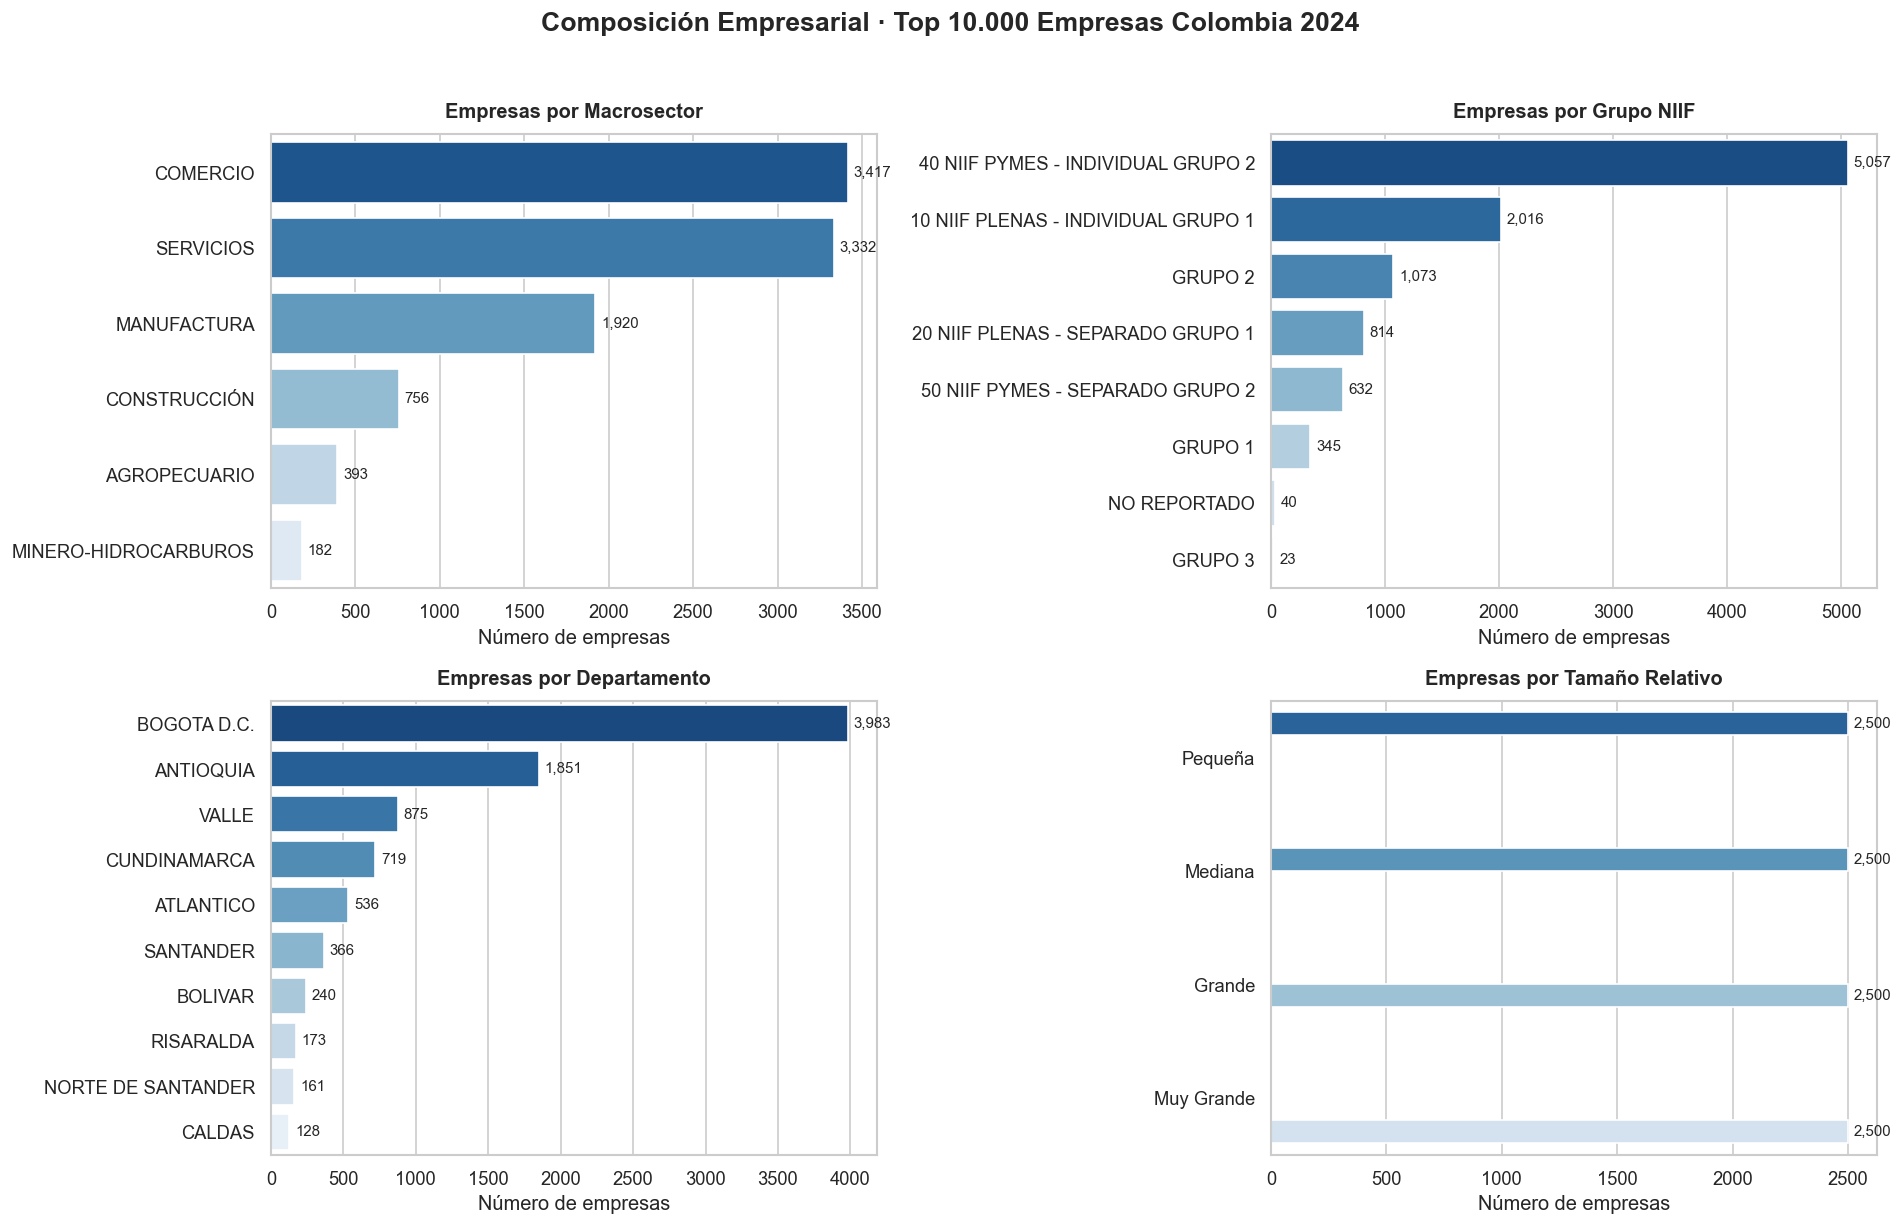

✓ Gráfica guardada


In [103]:
# Lienzo
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(16, 10)

# GRAFICOS

# 1. Macrosector
graficar_composicion(df=df,columna='MACROSECTOR',titulo='Empresas por Macrosector',ax=axes[0, 0])
# 2. Grupo NIIF
graficar_composicion(df=df,columna='GRUPO EN NIIF',titulo='Empresas por Grupo NIIF',ax=axes[0, 1])
# 3. Departamento
graficar_composicion(df=df,columna='DEPARTAMENTO DOMICILIO',titulo='Empresas por Departamento',ax=axes[1, 0],top_n=10)
# 4. Tamaño Empresa
graficar_composicion(df=df,columna='TAMAÑO EMPRESA',titulo='Empresas por Tamaño Relativo',ax=axes[1, 1])


# Ajustes
fig.suptitle('Composición Empresarial · Top 10.000 Empresas Colombia 2024',fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout()

# Guardar figura
plt.savefig('../outputs/01_composicion_empresas_por_segmento.png',bbox_inches='tight')
plt.show()
print('✓ Gráfica guardada')

### 6.2 Margen neto mediano por segmento (2024)

- ¿Qué macrosectores presentan mejores márgenes operativos?
- ¿Existen diferencias de rentabilidad según tamaño empresarial?
- ¿Qué grupos NIIF muestran mayor eficiencia operativa?

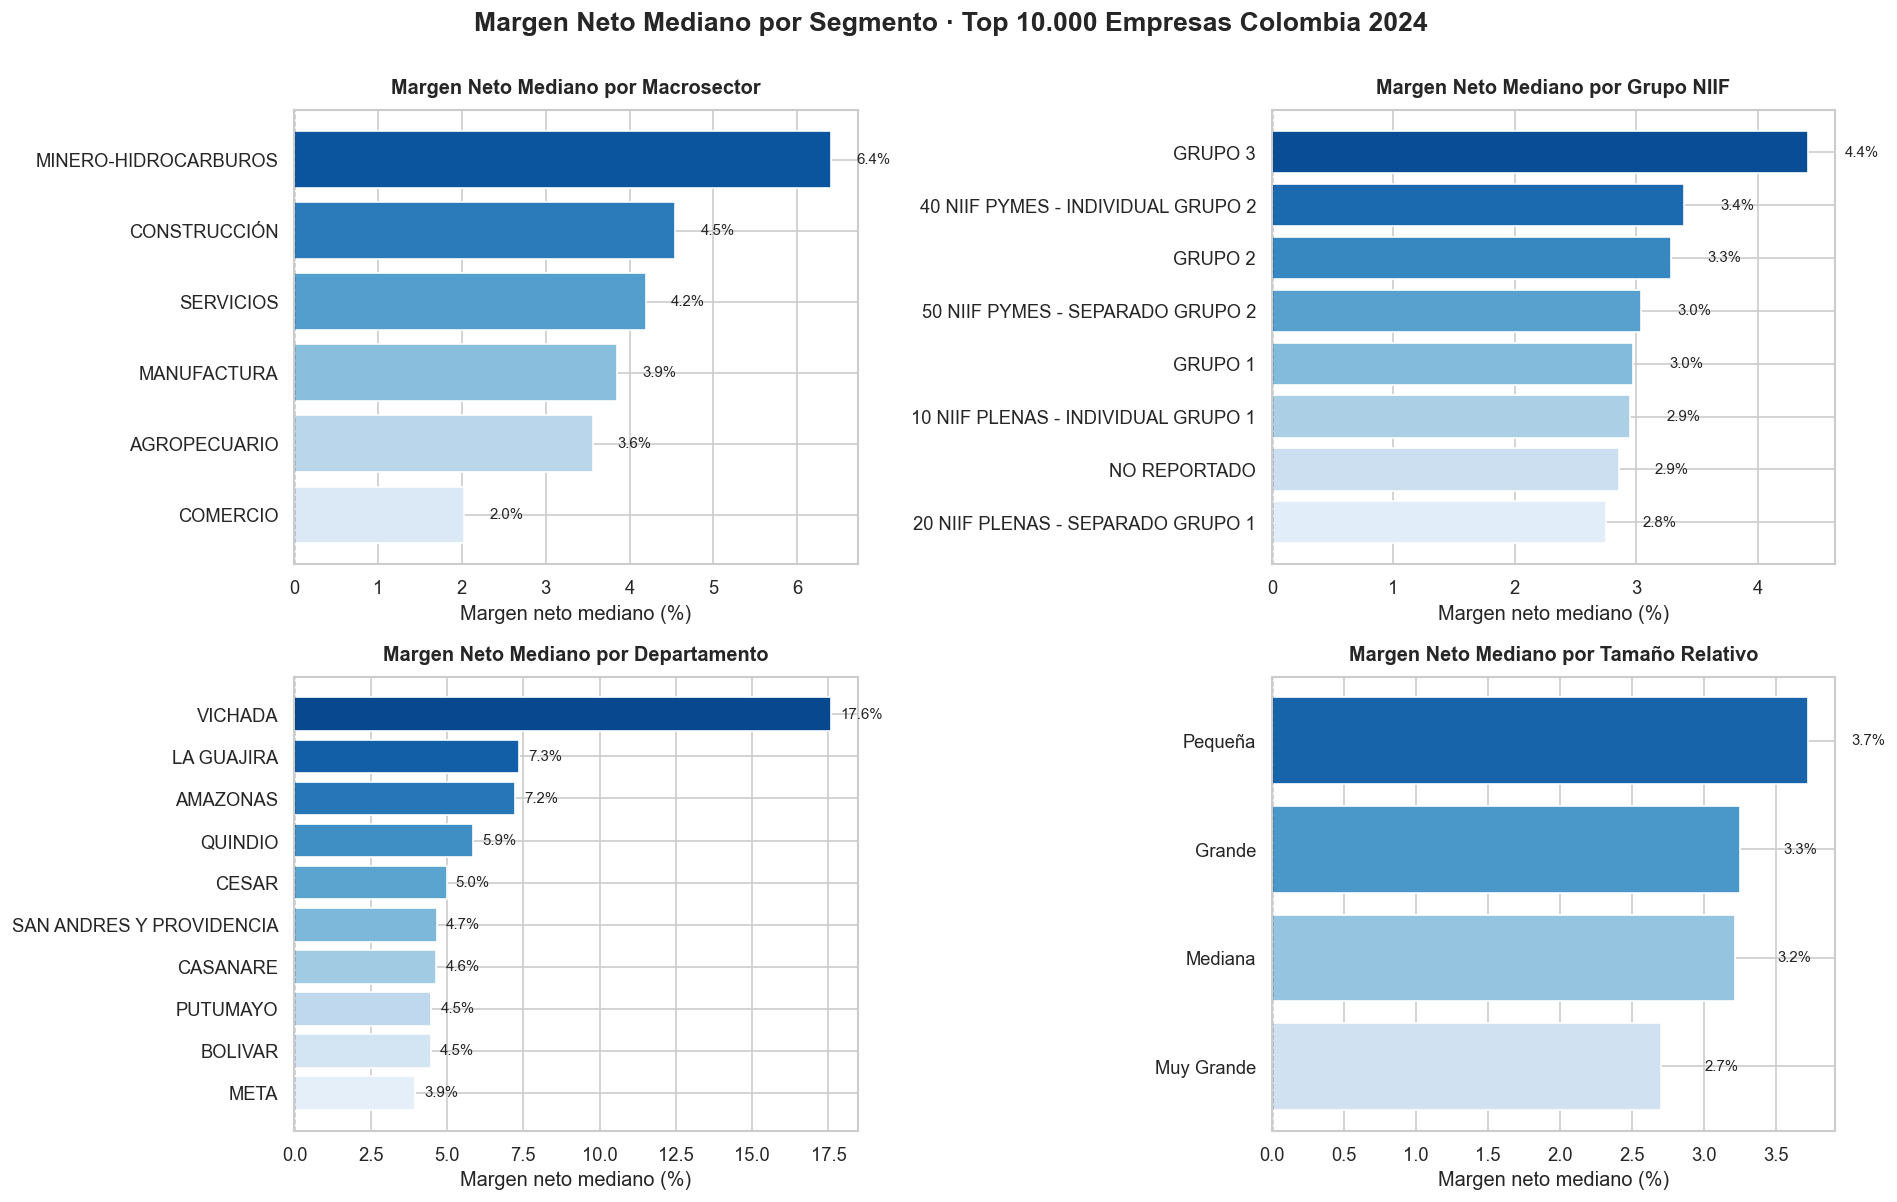

✓ Gráfica guardada


In [104]:
# Lienzo
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(16, 10)

# Graficos

# 1. Margen por macrosector
graficar_kpi_segmento(df=df,columna_segmento='MACROSECTOR',columna_kpi='MARGEN NETO 2024',
                      titulo='Margen Neto Mediano por Macrosector',ax=axes[0, 0])
# 2. Margen por grupo NIIF
graficar_kpi_segmento(df=df,columna_segmento='GRUPO EN NIIF',columna_kpi='MARGEN NETO 2024',
                      titulo='Margen Neto Mediano por Grupo NIIF',ax=axes[0, 1])
# 3. Margen por departamento
graficar_kpi_segmento(df=df,columna_segmento='DEPARTAMENTO DOMICILIO',columna_kpi='MARGEN NETO 2024',
                      titulo='Margen Neto Mediano por Departamento',ax=axes[1, 0],top_n=10)
# 4. Margen por tamaño empresa
graficar_kpi_segmento(df=df,columna_segmento='TAMAÑO EMPRESA',columna_kpi='MARGEN NETO 2024',
                      titulo='Margen Neto Mediano por Tamaño Relativo',ax=axes[1, 1])

# Ajustes
fig.suptitle('Margen Neto Mediano por Segmento · Top 10.000 Empresas Colombia 2024',
              fontsize=16,fontweight='bold',y=1)

# Guardar Figura
plt.tight_layout()
plt.savefig('../outputs/02_MARGEN_NETO_por_segmento.png',bbox_inches='tight')
plt.show()
print('✓ Gráfica guardada')


### 6.3 ROA mediano por segmento (2024)

- ¿Qué sectores utilizan mejor sus activos?
- ¿Qué segmentos presentan mayor dispersión en rentabilidad?
- ¿Existen sectores financieramente más estables?

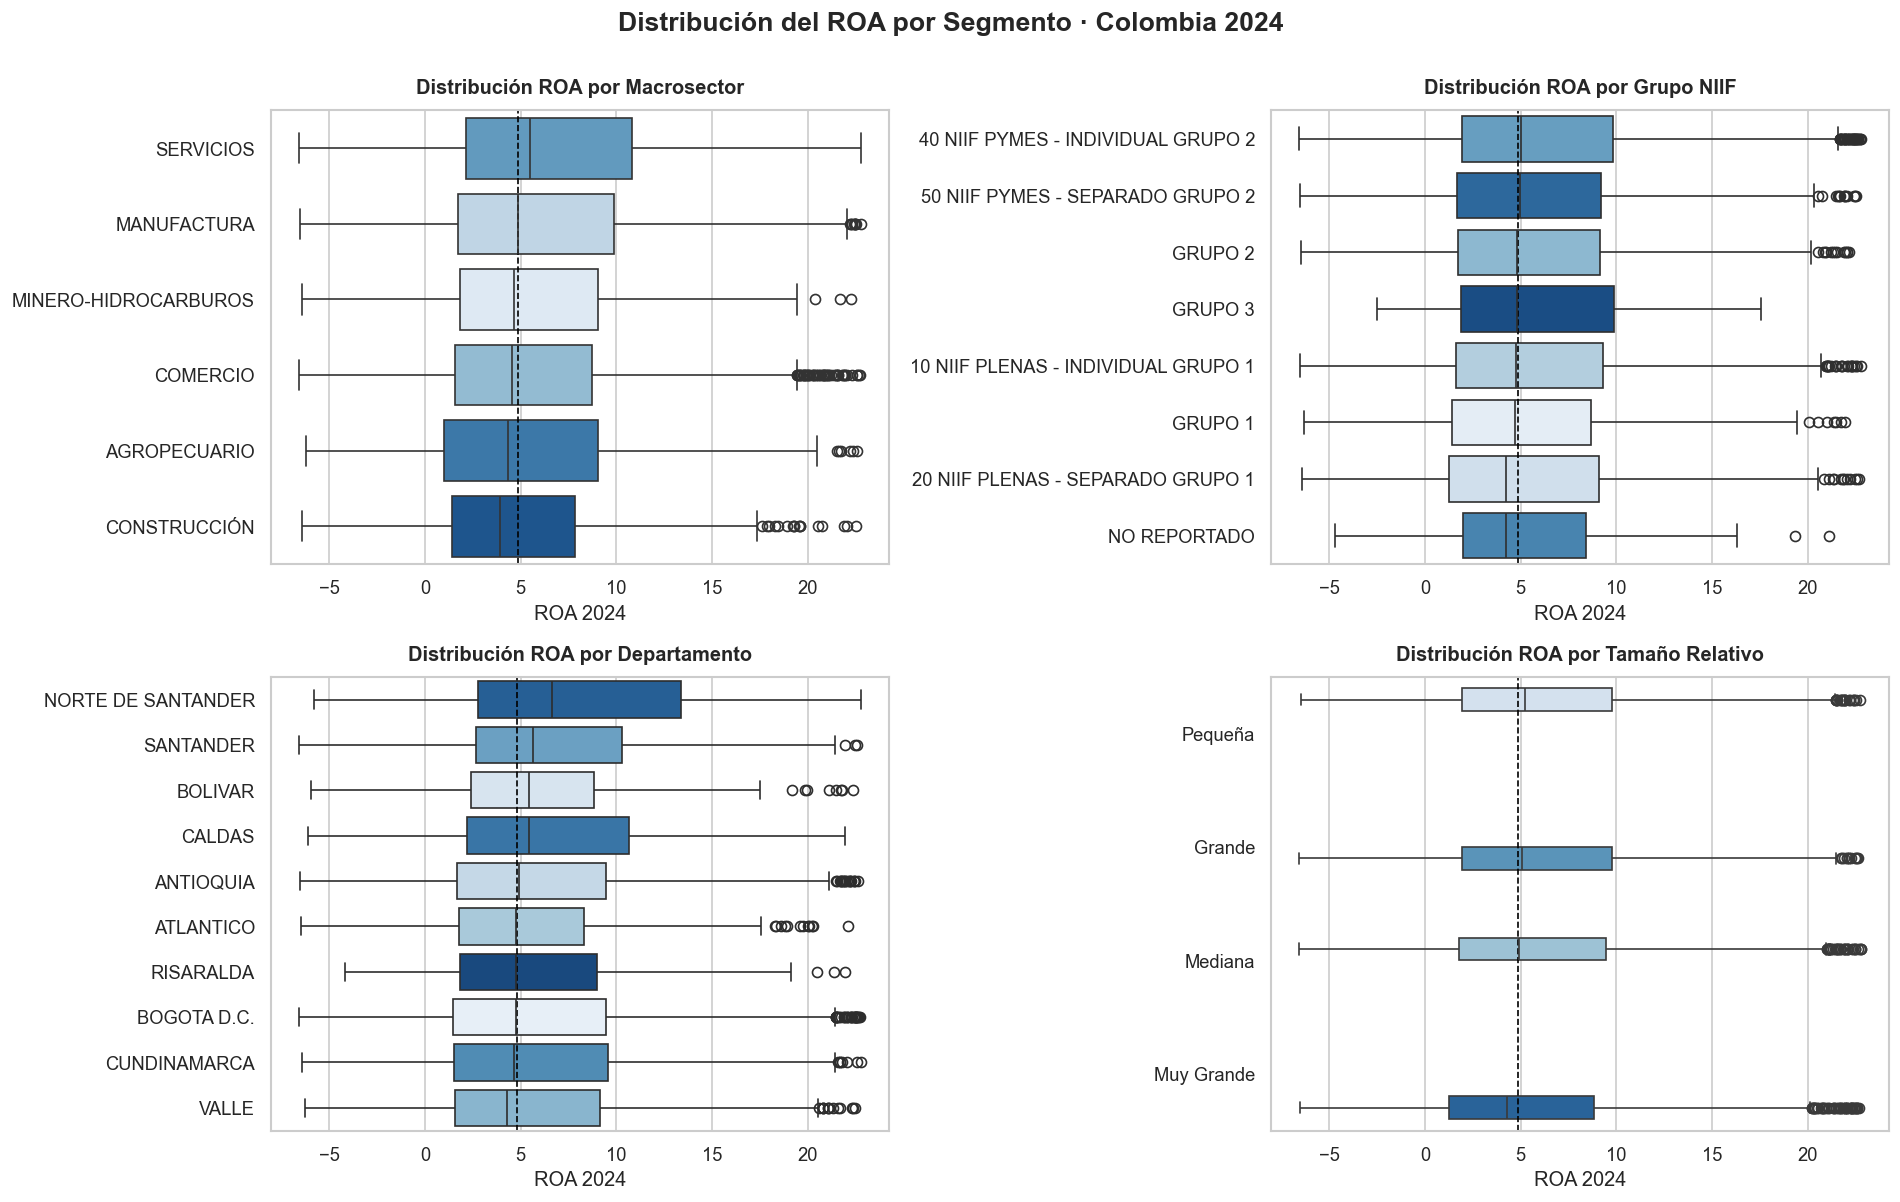

In [105]:
# Lienzo
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(16, 10)


# 1. ROA por macrosector
graficar_boxplot_kpi(df=df,columna_segmento='MACROSECTOR',columna_kpi='ROA 2024',
                     titulo='Distribución ROA por Macrosector',ax=axes[0, 0])

# 2. ROA por grupo NIIF
graficar_boxplot_kpi(df=df,columna_segmento='GRUPO EN NIIF',columna_kpi='ROA 2024',
                     titulo='Distribución ROA por Grupo NIIF',ax=axes[0, 1])

# 3. ROA por ubicacion geografica
graficar_boxplot_kpi(df=df,columna_segmento='DEPARTAMENTO DOMICILIO',columna_kpi='ROA 2024',
                     titulo='Distribución ROA por Departamento',ax=axes[1, 0],top_n=10)

# 4. ROA por tamaño relativo
graficar_boxplot_kpi(df=df,columna_segmento='TAMAÑO EMPRESA',columna_kpi='ROA 2024',
                     titulo='Distribución ROA por Tamaño Relativo',ax=axes[1, 1])

# Ajustes
fig.suptitle('Distribución del ROA por Segmento · Colombia 2024',
             fontsize=16,fontweight='bold',y=1)

# Guardar Figura
plt.tight_layout()
plt.savefig('../outputs/03_ROA_boxplot_segmentos.png',bbox_inches='tight')
plt.show()

### 6.4 ROE mediano por segmento (2024)

- ¿Qué segmentos generan mejor retorno para accionistas?
- ¿Qué industrias muestran mayor volatilidad financiera?
- ¿Existen diferencias significativas según tamaño empresarial?

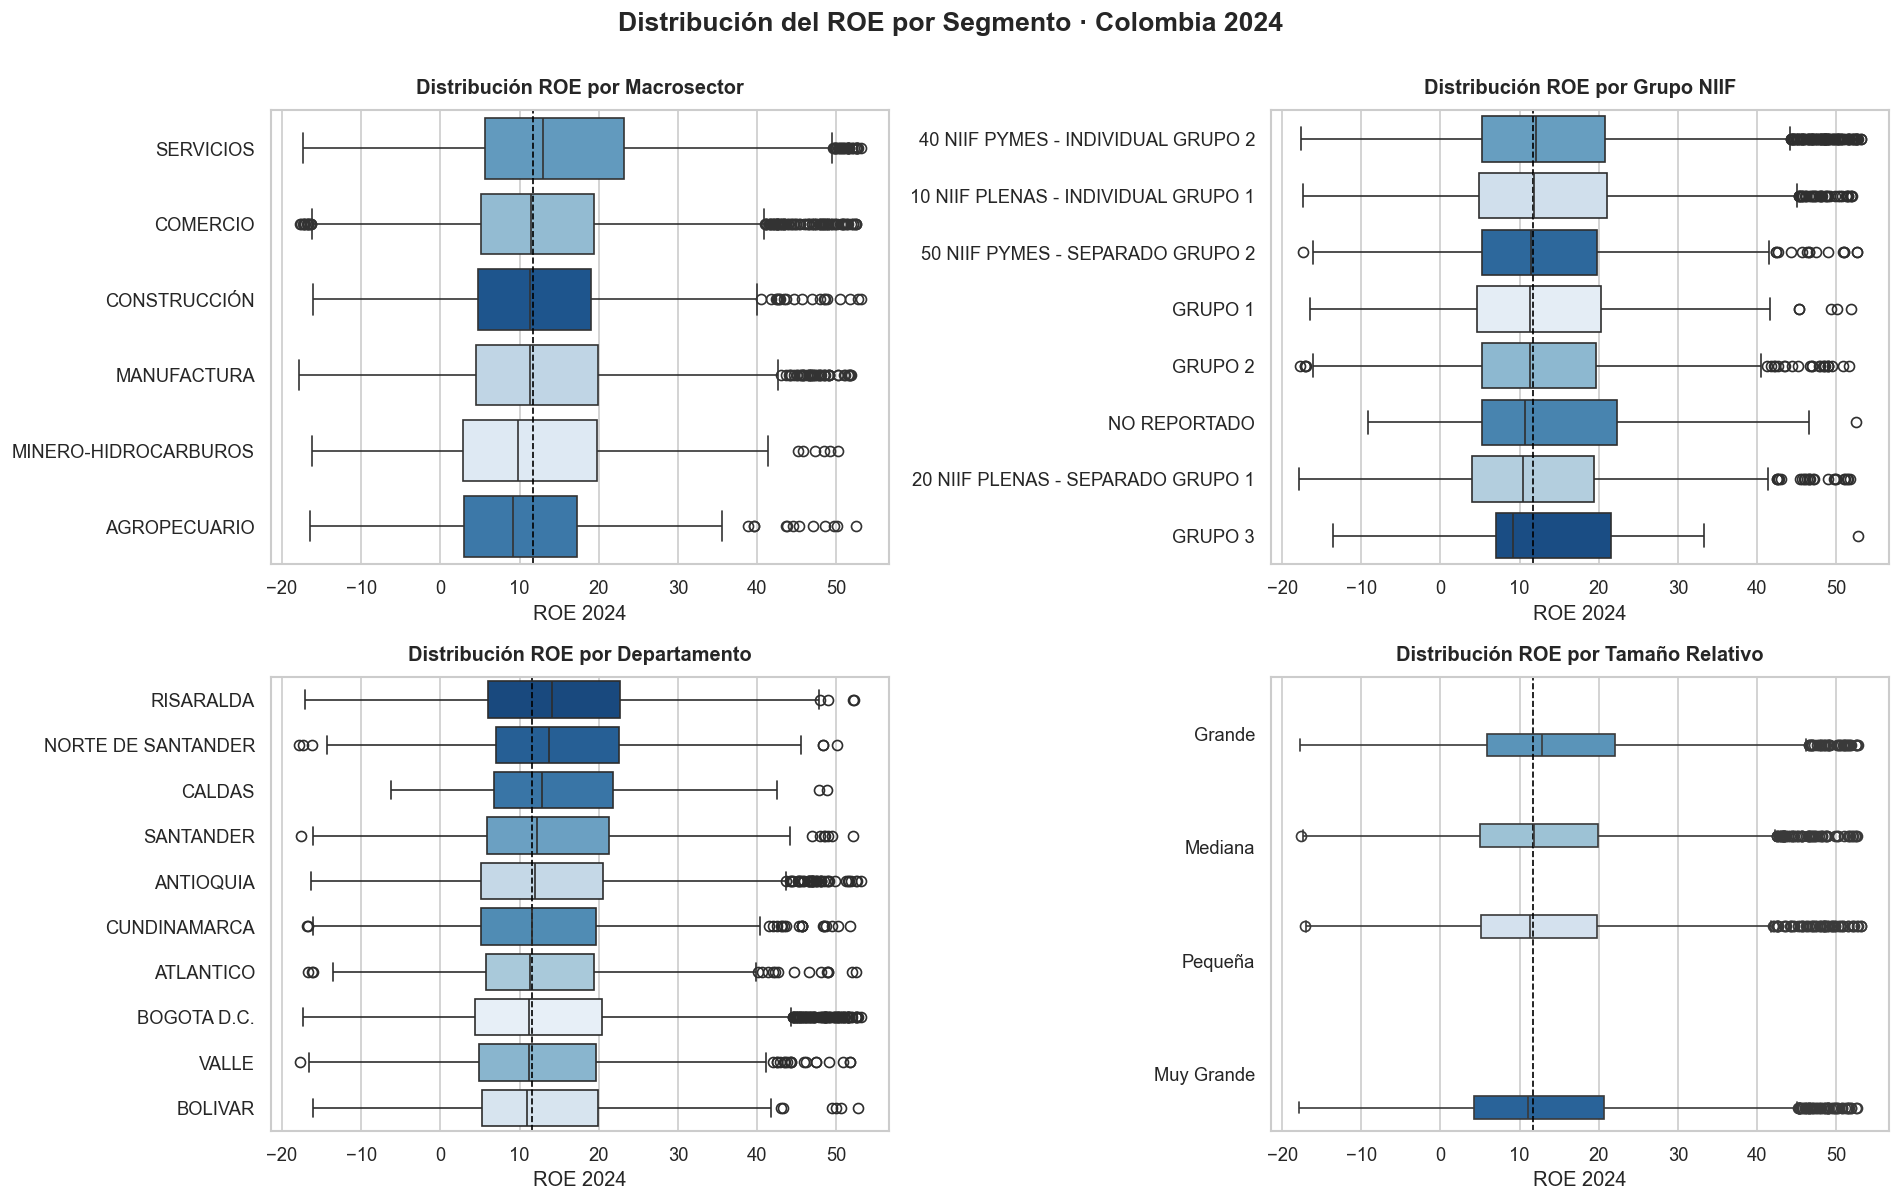

In [106]:
df_roe = df[(df['TOTAL PATRIMONIO 2024'] > 0) & (df['ROE 2024'].notna())].copy()

# Lienzo
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(16, 10)

# 1. ROE por macrosector
graficar_boxplot_kpi(df=df_roe,columna_segmento='MACROSECTOR',columna_kpi='ROE 2024',
    titulo='Distribución ROE por Macrosector',ax=axes[0, 0])

# 2. ROE por grupo NIIF
graficar_boxplot_kpi(df=df_roe,columna_segmento='GRUPO EN NIIF',columna_kpi='ROE 2024',
    titulo='Distribución ROE por Grupo NIIF',ax=axes[0, 1])

# 3. ROE por ubicación geográfica
graficar_boxplot_kpi(df=df_roe,columna_segmento='DEPARTAMENTO DOMICILIO',columna_kpi='ROE 2024',
    titulo='Distribución ROE por Departamento',ax=axes[1, 0],top_n=10)

# 4. ROE por tamaño relativo
graficar_boxplot_kpi(df=df_roe,columna_segmento='TAMAÑO EMPRESA',columna_kpi='ROE 2024',
    titulo='Distribución ROE por Tamaño Relativo',ax=axes[1, 1])

# Ajustes 
fig.suptitle('Distribución del ROE por Segmento · Colombia 2024',
    fontsize=16,fontweight='bold',y=1)

# Guardar figura
plt.tight_layout()
plt.savefig('../outputs/04_ROE_boxplot_segmentos.png',bbox_inches='tight')
plt.show()

### 6.5 Endeudamiento mediano por segmento (2024)

- ¿La mayoría de empresas presentan bajo o alto apalancamiento?
- ¿Existe concentración en niveles moderados de deuda?
- ¿La distribución del endeudamiento es asimétrica?

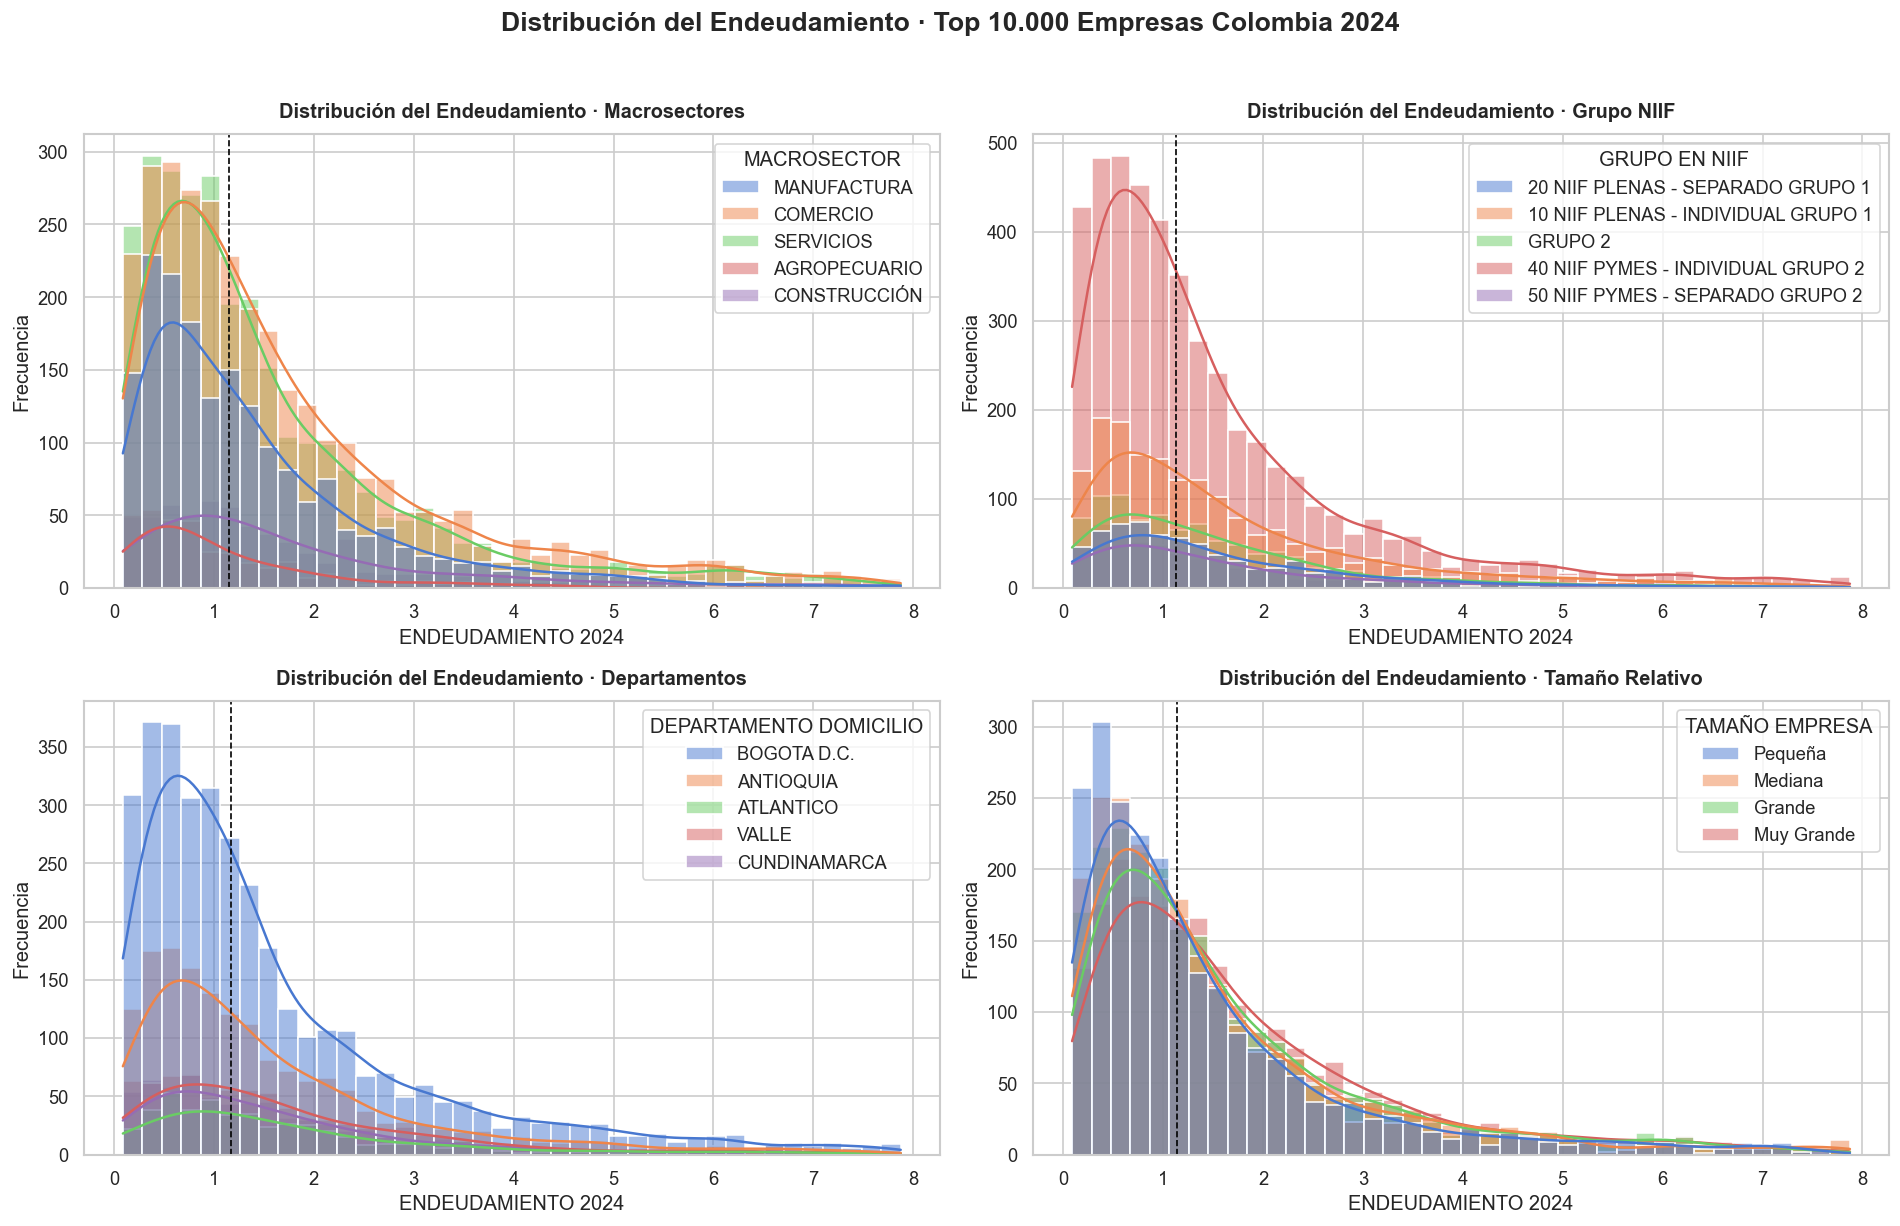

In [107]:
# Lienzo
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(16, 10)

# 1. Distribución por macrosector
graficar_distribucion_kpi(df=df,columna_segmento='MACROSECTOR',columna_kpi='ENDEUDAMIENTO 2024',
    titulo='Distribución del Endeudamiento · Macrosectores',ax=axes[0, 0])

# 2. Distribución por grupo NIIF
graficar_distribucion_kpi(df=df,columna_segmento='GRUPO EN NIIF',columna_kpi='ENDEUDAMIENTO 2024',
    titulo='Distribución del Endeudamiento · Grupo NIIF',ax=axes[0, 1])

# 3. Distribución por departamento
graficar_distribucion_kpi(df=df,columna_segmento='DEPARTAMENTO DOMICILIO',columna_kpi='ENDEUDAMIENTO 2024',
    titulo='Distribución del Endeudamiento · Departamentos',ax=axes[1, 0])

# 4. Distribución por tamaño empresa
graficar_distribucion_kpi(df=df,columna_segmento='TAMAÑO EMPRESA',columna_kpi='ENDEUDAMIENTO 2024',
    titulo='Distribución del Endeudamiento · Tamaño Relativo',ax=axes[1, 1])

# Ajustes
fig.suptitle('Distribución del Endeudamiento · Top 10.000 Empresas Colombia 2024',
             fontsize=16,fontweight='bold',y=1.02)

# Guardar figura
plt.tight_layout()
plt.savefig('../outputs/05_ENDEUDAMIENTO_distribucion_segmentos.png',bbox_inches='tight')
plt.show()

### 6.6 Top 20 empresas por ROE 2024

- ¿Qué empresas generaron la mayor rentabilidad para sus accionistas en Colombia durante 2024?
- ¿Las empresas con mayor ROE reflejan eficiencia financiera o altos niveles de apalancamiento?

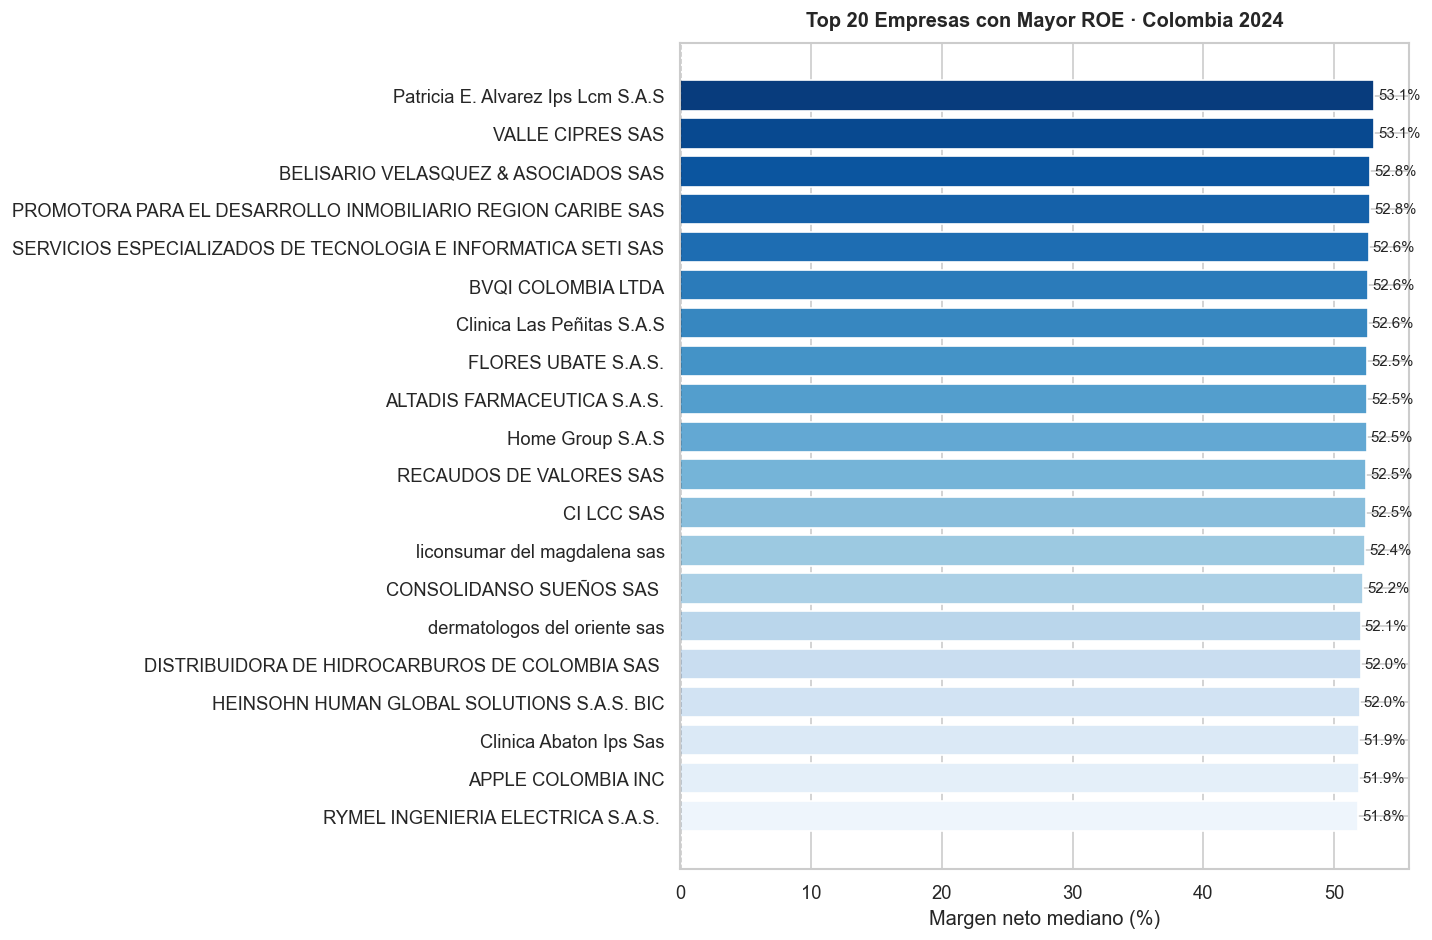

In [108]:
fig, ax = plt.subplots(figsize=(12, 8))

graficar_kpi_segmento(df=df_roe,columna_segmento='RAZON SOCIAL',columna_kpi='ROE 2024',
    titulo='Top 20 Empresas con Mayor ROE · Colombia 2024',ax=ax,top_n=20,agrupar=False)

plt.tight_layout()
plt.savefig('../outputs/06_TOP_20_ROE.png',bbox_inches='tight')
plt.show()

### 6.7 Empresas con crecimiento eficiente 2023→2024

- ¿Qué empresas lograron aumentar sus ingresos mientras mejoraban simultáneamente su rentabilidad operativa?
- ¿Existen compañías que estén creciendo de forma sostenible y eficiente, sin deteriorar su margen neto ni su estructura patrimonial?

In [109]:
# Percentiles robustos
p5_crecimiento = df['CRECIMIENTO INGRESOS %'].quantile(0.05)
p95_crecimiento = df['CRECIMIENTO INGRESOS %'].quantile(0.95)

p5_margen = df['MARGEN NETO 2024'].quantile(0.05)
p95_margen = df['MARGEN NETO 2024'].quantile(0.95)



# ── Empresas eficientes
df_eficientes = df[
    # Empresas que crecieron
    (df['CRECIMIENTO INGRESOS %'] > 0) &
    # Mejora de margen
    (df['MARGEN NETO 2024'] > df['MARGEN NETO 2023']) &
    # Patrimonio sano
    (df['TOTAL PATRIMONIO 2024'] > 0) &
    # Filtrado robusto crecimiento
    (df['CRECIMIENTO INGRESOS %'].between(p5_crecimiento, p95_crecimiento)) &
    # Filtrado robusto margen
    (df['MARGEN NETO 2024'].between(p5_margen, p95_margen))].copy()

# ── Resumen general
print(f'Empresas con crecimiento eficiente: '
      f'{len(df_eficientes):,} de {len(df):,} '
      f'({len(df_eficientes)/len(df)*100:.1f}%)')

# ─────────────────────────────────────────────────────────────
# TOP EMPRESAS MÁS EFICIENTES
# ─────────────────────────────────────────────────────────────

top_eficientes = (df_eficientes.nlargest(15, 'CRECIMIENTO INGRESOS %')
    [['RANKING','RAZON SOCIAL','MACROSECTOR','CRECIMIENTO INGRESOS %','MARGEN NETO 2024','MARGEN NETO 2023','ROE 2024']]
    .reset_index(drop=True))

top_eficientes.index += 1

print('\n── Top 15 empresas · Crecimiento eficiente 2023→2024 ──')

display(top_eficientes.round(2))

Empresas con crecimiento eficiente: 2,823 de 10,000 (28.2%)

── Top 15 empresas · Crecimiento eficiente 2023→2024 ──


,RANKING,RAZON SOCIAL,MACROSECTOR,CRECIMIENTO INGRESOS %,MARGEN NETO 2024,MARGEN NETO 2023,ROE 2024
1,4412,EMPRESA DE VIGILANCIA Y SEGURIDAD PRIVADA SERV...,SERVICIOS,88.96,7.69,3.70,34.50
2,5365,INGEKAR LPR SAS,COMERCIO,88.35,5.22,4.91,23.84
3,2789,HIERROS MADEBELLO SAS,COMERCIO,87.87,1.61,0.84,31.98
4,1987,CROIL SERVICIOS E INGENIERIA SAS,CONSTRUCCIÓN,87.66,6.92,5.85,47.95
5,8567,INFRAESTRUCTURA INTEGRTAL SAS,SERVICIOS,87.57,14.83,10.66,30.16
6,1217,S&A SERVICIOS Y ASESORIAS SAS BIC,SERVICIOS,87.29,1.36,0.19,20.35
7,4415,JESMAR HURTADIO Y COMPAÑIA S EN C,COMERCIO,86.31,4.46,3.46,17.39
8,6565,RODRIGO SAMPER Y CIA SAS,SERVICIOS,85.85,6.10,5.28,32.49
9,4974,ARAJET - SUCURSAL COLOMBIA,SERVICIOS,85.65,-4.87,-34.99,-5.22
10,7774,DUMAR INGENIEROS SAS,CONSTRUCCIÓN,85.64,4.48,2.23,6.64


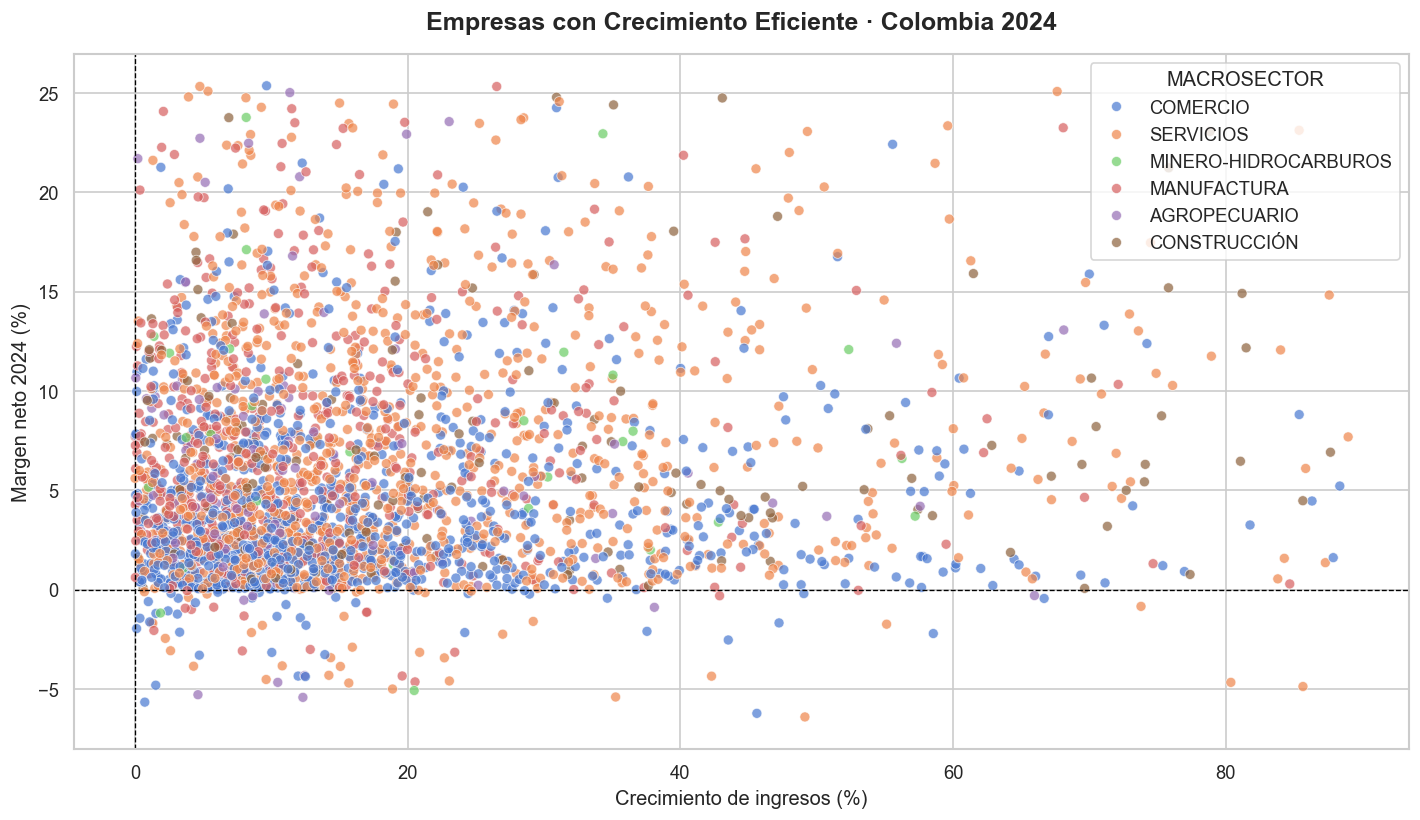

✓ Gráfica guardada


In [110]:
# Crecimiento vs Rentabilidad
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(data=df_eficientes,x='CRECIMIENTO INGRESOS %',y='MARGEN NETO 2024',hue='MACROSECTOR',alpha=0.7,ax=ax)

# Líneas de referencia
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

# Títulos
ax.set_title('Empresas con Crecimiento Eficiente · Colombia 2024',
    fontsize=15,fontweight='bold',pad=15)

ax.set_xlabel('Crecimiento de ingresos (%)')
ax.set_ylabel('Margen neto 2024 (%)')

plt.tight_layout()
plt.savefig('../outputs/07_empresas_crecimiento_eficiente.png',bbox_inches='tight')
plt.show()
print('✓ Gráfica guardada')

### 6.8 Mapa de rentabilidad vs riesgo de apalancamiento por macrosector

- ¿Qué macrosectores presentan el mejor equilibrio entre rentabilidad y riesgo financiero?
- ¿Existen sectores con altos niveles de rentabilidad acompañados de estructuras financieras más apalancadas?



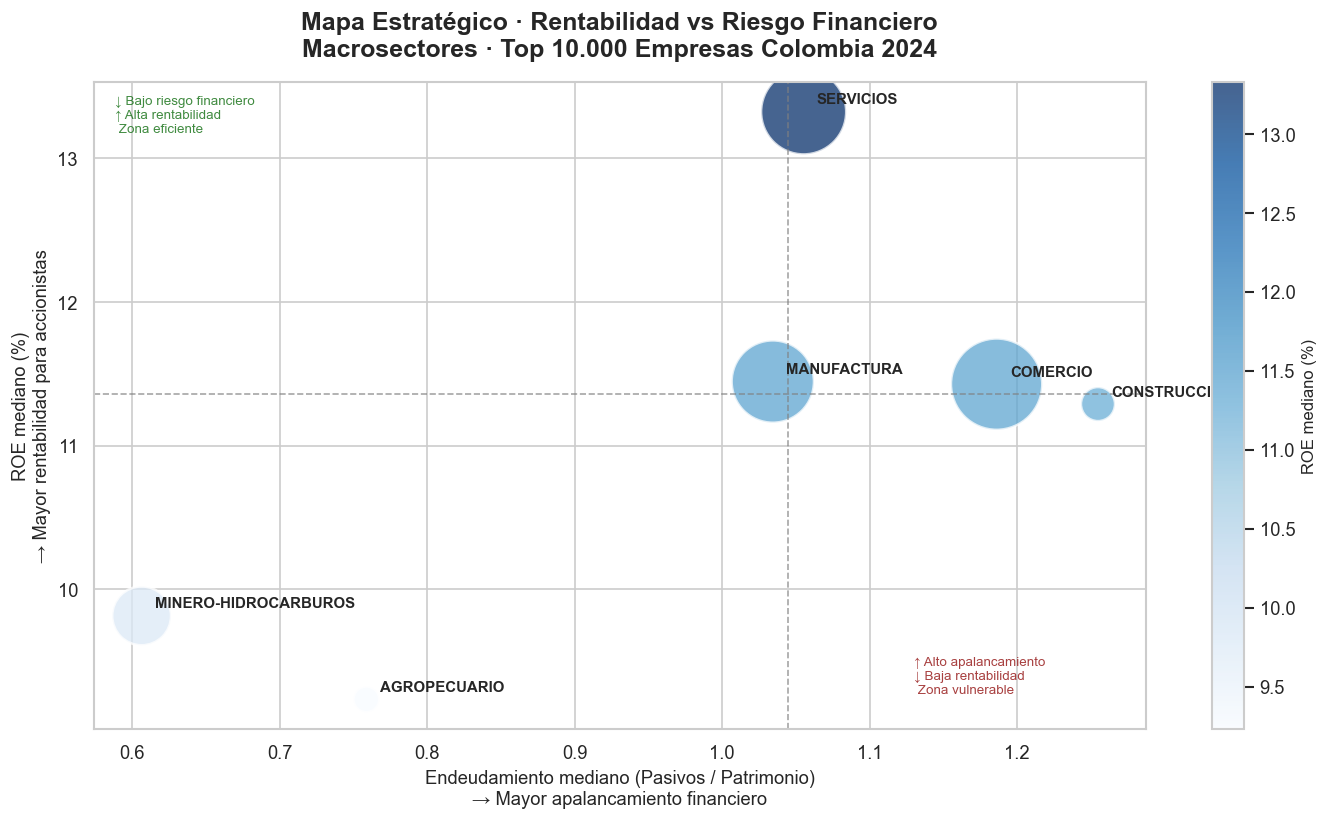

✓ Gráfica guardada


In [111]:
# MAPA ESTRATÉGICO · RENTABILIDAD VS RIESGO

# ── Filtrado robusto mediante percentiles
p5_roe = df['ROE 2024'].quantile(0.05)
p95_roe = df['ROE 2024'].quantile(0.95)

p5_end = df['ENDEUDAMIENTO 2024'].quantile(0.05)
p95_end = df['ENDEUDAMIENTO 2024'].quantile(0.95)

# ── Dataset limpio para visualización
df_scatter = df[(df['TOTAL PATRIMONIO 2024'] > 0) &
                (df['ROE 2024'].between(p5_roe, p95_roe)) &
                (df['ENDEUDAMIENTO 2024'].between(p5_end, p95_end))].copy()


mapa = (df_scatter.groupby('MACROSECTOR').agg(
        ROE_mediano = ('ROE 2024', 'median'),
        Endeudamiento_mediano = ('ENDEUDAMIENTO 2024','median'),
        Ingresos_totales = ('INGRESOS OPERACIONALES 2024*','sum'),
        N_empresas = ('RAZON SOCIAL','count')).reset_index())


# Visualizacion
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(x=mapa['Endeudamiento_mediano'],y=mapa['ROE_mediano'],
    s=(mapa['Ingresos_totales'] / mapa['Ingresos_totales'].max()) * 3000, # Tamaño burbuja
    c=mapa['ROE_mediano'], # Color
    cmap='Blues',
    alpha=0.75,
    edgecolors='white',
    linewidths=1.5)

for _, row in mapa.iterrows():

    ax.annotate(row['MACROSECTOR'],(row['Endeudamiento_mediano'],row['ROE_mediano']),
        textcoords='offset points',xytext=(8, 5),fontsize=9,fontweight='bold')

ax.axvline(mapa['Endeudamiento_mediano'].median(),
    color='gray',linestyle='--',linewidth=1,alpha=0.7)
ax.axhline(mapa['ROE_mediano'].median(),
    color='gray',linestyle='--',linewidth=1,alpha=0.7)

# Cuadrantes
ax.text(0.02,0.98,'↓ Bajo riesgo financiero\n↑ Alta rentabilidad\n Zona eficiente',
    transform=ax.transAxes,fontsize=8,color='darkgreen',va='top',alpha=0.75)

ax.text(0.78,0.05,'↑ Alto apalancamiento\n↓ Baja rentabilidad\n Zona vulnerable',
    transform=ax.transAxes,fontsize=8,color='darkred',va='bottom',alpha=0.75)

# Titulos
ax.set_title('Mapa Estratégico · Rentabilidad vs Riesgo Financiero\n'
            'Macrosectores · Top 10.000 Empresas Colombia 2024',
            fontsize=15,fontweight='bold',pad=16)
ax.set_xlabel('Endeudamiento mediano (Pasivos / Patrimonio)\n'
            '→ Mayor apalancamiento financiero',
            fontsize=11)
ax.set_ylabel('ROE mediano (%)\n'
            '→ Mayor rentabilidad para accionistas',
            fontsize=11)

cbar = plt.colorbar(scatter)
cbar.set_label('ROE mediano (%)',fontsize=10)

# Ajustes
plt.tight_layout()
plt.savefig('../outputs/08_mapa_rentabilidad_riesgo.png',dpi=150,bbox_inches='tight')
plt.show()
print('✓ Gráfica guardada')

---
## 7. Exportación de Datos para Power BI

Se exporta el dataset enriquecido con todos los KPIs calculados.
Este archivo es la fuente única para el dashboard de Power BI.

In [112]:
ruta_output = Path('../outputs/10000_Empresas_Final.csv')
df.to_csv(ruta_output, index=False, encoding='utf-8-sig')

print(f'✓ Dataset exportado: {ruta_output}')
print(f'  Registros: {len(df):,}')
print(f'  Columnas: {df.shape[1]}')

✓ Dataset exportado: ..\outputs\10000_Empresas_Final.csv
  Registros: 10,000
  Columnas: 32


---
## 8. Hallazgos Principales del EDA

> Análisis de 10.000 empresas · Supersociedades Colombia · Corte 31 dic 2024  
> Estadístico central: **mediana** (robusta ante la alta dispersión)

---

### 🔍 H1 · El tamaño no garantiza eficiencia operativa
Las empresas del cuartil "Pequeño" registraron el **mayor margen neto mediano (3.7%)**,
superando a las "Muy Grandes" (2.7%). Las Pymes bajo NIIF Grupo 2-3 consistentemente
superan a las NIIF Plenas Grupo 1 en eficiencia de margen.
**Ser grande en ingresos no equivale a ser rentable operativamente.**

---

### 🔍 H2 · Las grandes empresas compensan con apalancamiento
El patrón se invierte en ROE: las empresas grandes superan a las pequeñas en
rentabilidad para el accionista. El ROE mediano de la masa estudiada cayó de **13.27% (2023)**
a **11.97% (2024)** — la mayor caída entre todos los KPIs. Las grandes corporaciones
usan deuda estratégicamente para amplificar retornos sobre patrimonio.

---

### 🔍 H3 · Minero-Hidrocarburos: máximo margen, mínimo riesgo, menor ROE
Con solo el **1.8% del universo (182 empresas)**, lidera en margen neto mediano (**6.4%**)
y tiene el menor endeudamiento (**0.6×**). Paradójicamente registra el **ROE más bajo
(≈9.9%)** porque sus patrimonios enormes diluyen el retorno. Es el sector más conservador
del mapa estratégico.

---

### 🔍 H4 · Servicios: mayor ROE, mayor riesgo
El sector Servicios (El 33.3% de las empresas) registra el **mayor ROE mediano
(≈13.3%)** pero también el mayor nivel de endeudamiento (**≈1.04×**). Alta rentabilidad
con alto apalancamiento: perfil atractivo pero vulnerable ante tasas de interés elevadas
o desaceleración del consumo.

---

### 🔍 H5 · 2024: ajuste defensivo, no deterioro estructural
Los tres indicadores de rentabilidad cayeron simultáneamente (Margen **-0.28pp**,
ROA **-0.54pp**, ROE **-1.30pp**), pero los de riesgo mejoraron (Solvencia **+0.04×**,
Endeudamiento **-0.06×**). Las empresas colombianas sacrificaron rentabilidad para
reducir exposición financiera — patrón consistente con el entorno de tasas de interés
históricamente altas en Colombia durante 2023-2024.
